<img src = "img/images.png" style="height:80px;">
<div style="text-align:center;">
    
# REDES NEURONALES

<img src ="img/Python-Logo.jpg" style="height:222px;">

    Abril 11, 2026

</div>

### _Esteban Sáncez_

In [1]:
#Importemos TensorFlow 2.X y Numpy
import numpy as np
import tensorflow as tf
tf.__version__

'2.21.0'

In [82]:
# Importamos el dataset MNIST y cargamos los datos
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


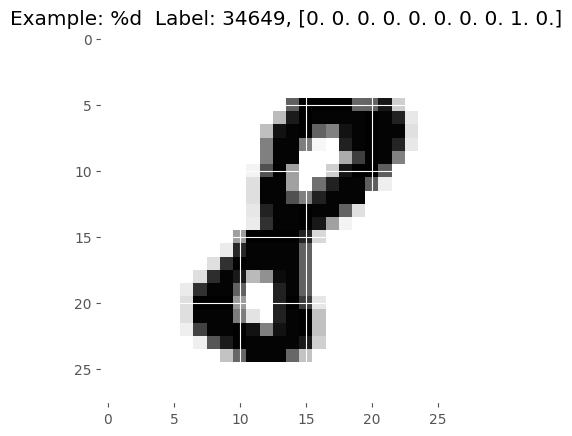

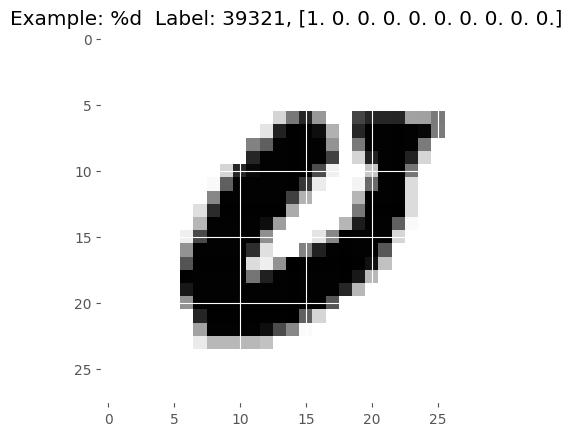

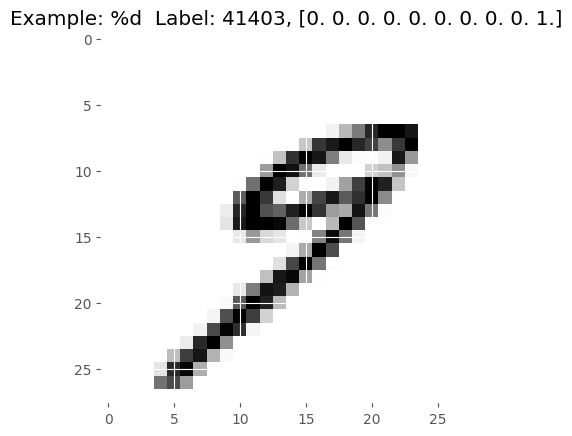

In [101]:
import matplotlib.pyplot as plt
# Función auxiliar para visualizar datos de entrenamiento de manera aleatoria
def display_digit(num, x_train, y_train):
    # Seleccionar la imagen num de mnist.train.images y hacer un reshape al tamaño de la imagen
    image = x_train[num,:,:]
    # Seleccionar el target num de mnist.train.labels
    label = y_train[num]
    # Mostrar
    plt.title(f'Example: %d  Label: {num}, {label}')
    plt.imshow(image, cmap=plt.get_cmap('gray_r'))
    plt.show()

# Mostramos algunos ejemplos
display_digit(np.random.randint(0, x_train.shape[0]), x_train, y_train)
display_digit(np.random.randint(0, x_train.shape[0]), x_train, y_train)
display_digit(np.random.randint(0, x_train.shape[0]), x_train, y_train)

In [85]:
# Pre-procesado obligatorio cuando trabajo con redes neuronales
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

x_train, x_te = x_train / 255.0, x_test / 255.0 #Cambio al rango 0-1 -> Disminuyo CC
y_train = to_categorical(y_train, num_classes=10) #One-hot encoding para minimizar error
print(y_train.shape)
y_te = to_categorical(y_test, num_classes=10)

x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train, test_size=0.1,
                                             random_state=42) # 3 subconjuntos es de vital importancia
print(y_tr.shape)

(60000, 10)
(54000, 10)


In [86]:
print(y_tr[1])

[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [87]:
print(y_tr[1].argmax(axis=0))

6


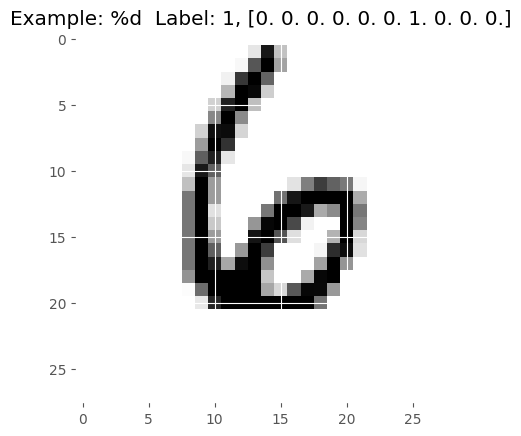

In [88]:
display_digit(1, x_tr, y_tr)

In [89]:
# Voy a necesitar importar una serie de modulos para programar mi red neuronal
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Input, Dropout, BatchNormalization

######### Modelo funcional ############
# Definir la entrada
input_layer = Input(shape=(28, 28))
# Capa de aplanamiento
x = Flatten()(input_layer)
# Capas ocultas con Dropout y BatchNormalization para regularizar
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
# Capa salida -> Mismo número de neuronas que de clases objetivo
output_layer = Dense(10, activation='softmax')(x)
# Crear el modelo
model = Model(inputs=input_layer, outputs=output_layer)
print(model.summary())

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 538,890 (2.06 MB)

 Trainable params: 537,354 (2.05 MB)

 Non-trainable params: 1,536 (6.00 KB)

None


In [91]:
# Por fin podemos entrenar nuestra primera red neuronal
print("[INFO]: Entrenando red neuronal...")
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
H = model.fit(x_tr, y_tr, validation_data=(x_val, y_val), epochs=50, batch_size=128)

[INFO]: Entrenando red neuronal...
Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9965 - loss: 0.0113 - val_accuracy: 0.9870 - val_loss: 0.0656
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9956 - loss: 0.0124 - val_accuracy: 0.9860 - val_loss: 0.0656
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9956 - loss: 0.0130 - val_accuracy: 0.9878 - val_loss: 0.0625
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9969 - loss: 0.0105 - val_accuracy: 0.9873 - val_loss: 0.0630
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9964 - loss: 0.0112 - val_accuracy: 0.9870 - val_loss: 0.0620
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9967 - loss: 0.0095 - val_accuracy: 0.9868 - val_loss: 0.0610
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9963 - loss: 0.0103 - val_accuracy: 0.9882 - val_loss: 0.0604
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accu

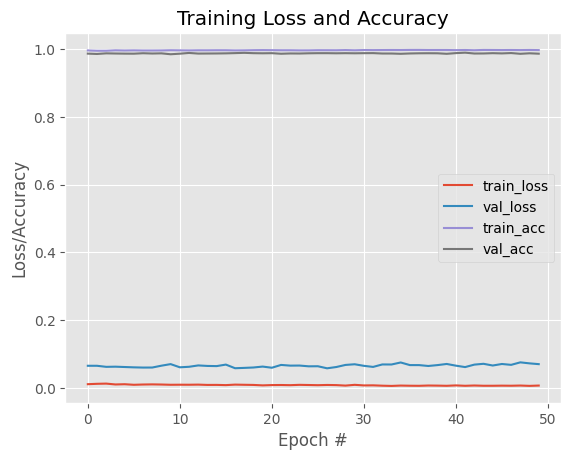

In [92]:
# Muestro gráfica de accuracy y losses
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 50), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 50), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 50), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 50), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

In [93]:
from sklearn.metrics import classification_report
# Evaluando el modelo de predicción con las imágenes de test
print("[INFO]: Evaluando red neuronal...")
predictions = model.predict(x_te, batch_size=128)
print(y_te[0])
print(predictions[0])
print(classification_report(y_te.argmax(axis=1), predictions.argmax(axis=1)))

[INFO]: Evaluando red neuronal...
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
[1.1268123e-11 7.4783971e-11 2.6332303e-09 1.1893306e-09 1.0625657e-11
 3.4946024e-10 4.4903789e-13 1.0000000e+00 1.8688736e-11 5.4194330e-11]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.99      0.99      1032
           3       0.98      0.99      0.98      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.98      0.99       958
           7       0.99      0.98      0.98      1028
           8       0.99      0.98      0.98       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     

In [94]:
predictions[0].argmax(axis=0)

np.int64(7)

In [95]:
y_te[0].argmax(axis=0)

np.int64(7)

In [96]:
print(model.summary())

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,613,600 (6.16 MB)

 Trainable params: 537,354 (2.05 MB)

 Non-trainable params: 1,536 (6.00 KB)

 Optimizer params: 1,074,710 (4.10 MB)

None


In [110]:
import cv2
import numpy as np

def preprocesar_imagen(ruta_imagen):
    # Leer en escala de grises
    img = cv2.imread(ruta_imagen, cv2.IMREAD_GRAYSCALE)
    
    # Redimensionar si la foto es muy grande (acelera procesamiento)
    img = cv2.resize(img, (400, 400), interpolation=cv2.INTER_AREA)
    
    # Desenfoque gaussiano para eliminar ruido de la foto
    img_blur = cv2.GaussianBlur(img, (7, 7), 0)
    
    # Umbralización adaptativa -> maneja sombras y luz desigual
    # (mejor que Otsu para fotos reales)
    img_thresh = cv2.adaptiveThreshold(
        img_blur, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        blockSize=31,  # área local para calcular el umbral
        C=10           # constante de ajuste
    )
    
    # Operación morfológica para engrosar el trazo
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    img_thresh = cv2.dilate(img_thresh, kernel, iterations=2)
    
    # Recortar solo la región del dígito (bounding box)
    coords = cv2.findNonZero(img_thresh)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        padding = 30
        x = max(0, x - padding)
        y = max(0, y - padding)
        w = min(img.shape[1] - x, w + 2 * padding)
        h = min(img.shape[0] - y, h + 2 * padding)
        img_thresh = img_thresh[y:y+h, x:x+w]
    
    # Redimensionar a 28x28 -> formato MNIST
    img_28 = cv2.resize(img_thresh, (28, 28), interpolation=cv2.INTER_AREA)
    
    # Normalizar al rango 0-1 -> Disminuyo CC
    img_norm = img_28 / 255.0
    return img_norm, img

print('Función preprocesar_imagen definida correctamente')

Función preprocesar_imagen definida correctamente


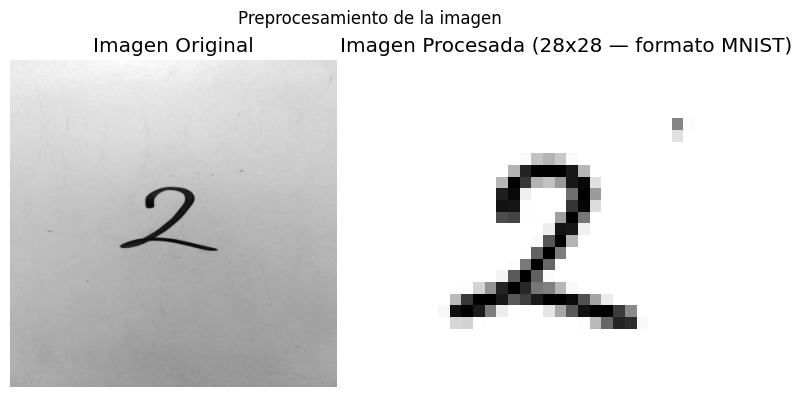

[INFO]: Evaluando red neuronal...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
[6.7123432e-11 7.7966295e-05 9.9992013e-01 8.5096836e-08 2.2794288e-12
 1.1876201e-06 1.2169645e-08 8.4991086e-08 5.7346034e-07 5.8985656e-13]
Dígito predicho: 2


In [111]:
import os

nombre_archivo = "numero.jpeg"  # <-- cambia esto por el nombre de tu foto

if not os.path.exists(nombre_archivo):
    raise FileNotFoundError(f"No se encontró el archivo: {nombre_archivo}. Asegúrate de colocarlo en la misma carpeta que el notebook.")

# Preprocesar
img_proc, img_original = preprocesar_imagen(nombre_archivo)

# Visualizar original vs procesada (igual que display_digit en clase)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_original, cmap='gray')
axes[0].set_title('Imagen Original')
axes[0].axis('off')
axes[1].imshow(img_proc, cmap=plt.get_cmap('gray_r'))
axes[1].set_title('Imagen Procesada (28x28 — formato MNIST)')
axes[1].axis('off')
plt.suptitle('Preprocesamiento de la imagen')
plt.tight_layout()
plt.show()

# Predicción
print("[INFO]: Evaluando red neuronal...")
img_input = img_proc.reshape(1, 28, 28)
pred = model.predict(img_input, batch_size=1)
print(pred[0])
print(f'Dígito predicho: {pred[0].argmax(axis=0)}')

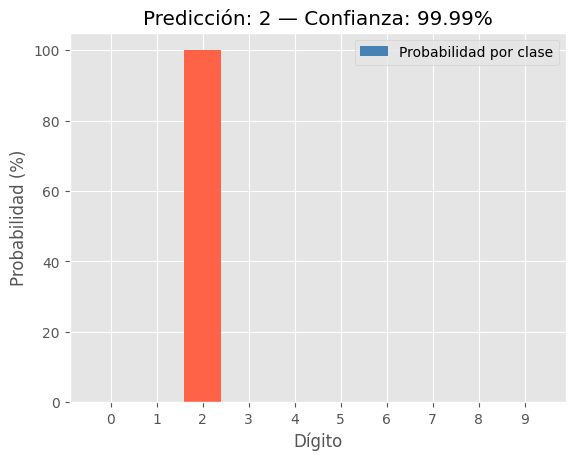

In [112]:
# Gráfica de probabilidades -> misma estructura que la gráfica de training
plt.style.use("ggplot")
plt.figure()
colores = ['tomato' if i == pred[0].argmax() else 'steelblue' for i in range(10)]
plt.bar(range(10), pred[0] * 100, color=colores)
plt.title(f'Predicción: {pred[0].argmax()} — Confianza: {pred[0].max()*100:.2f}%')
plt.xlabel('Dígito')
plt.ylabel('Probabilidad (%)')
plt.xticks(range(10))
plt.legend(['Probabilidad por clase'])

Repositorio en GitHub: (https://github.com/EstebanSan140106/Machine-E-Learning-2.git)